# Warm-up

Check the enviroment.


In [1]:
! python --version
! which python

Python 3.12.2
/Users/piotr/Projects/Thesis/fairseq/examples/MMPT/.venv/bin/python


## Load an ASL sign from Spreadthesign

In [2]:
'''! pip install -q mediapipe
! pip install -q vidgear
! pip install -q pose-format
! pip install -q git+https://github.com/sign-language-processing/transcription.git@1f2cef8'''

'! pip install -q mediapipe\n! pip install -q vidgear\n! pip install -q pose-format\n! pip install -q git+https://github.com/sign-language-processing/transcription.git@1f2cef8'

In [2]:
import mediapipe as mp

Download the video of the sign "house" in ASL and convcert it to a pose.

In [4]:
#! curl https://media.spreadthesign.com/video/mp4/13/58463.mp4 --output house.mp4
! video_to_pose -i house.mp4 --format mp -o house.pose

Traceback (most recent call last):
  File "/Users/piotr/Projects/Thesis/fairseq/examples/MMPT/.venv/lib/python3.12/site-packages/pose_format/utils/holistic.py", line 11, in <module>
    from mediapipe.python.solutions.face_mesh_connections import FACEMESH_IRISES
ModuleNotFoundError: No module named 'mediapipe.python'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/Users/piotr/Projects/Thesis/fairseq/examples/MMPT/.venv/bin/video_to_pose", line 4, in <module>
    from pose_format.bin.pose_estimation import main
  File "/Users/piotr/Projects/Thesis/fairseq/examples/MMPT/.venv/lib/python3.12/site-packages/pose_format/bin/pose_estimation.py", line 6, in <module>
    from pose_format.utils.holistic import load_holistic
  File "/Users/piotr/Projects/Thesis/fairseq/examples/MMPT/.venv/lib/python3.12/site-packages/pose_format/utils/holistic.py", line 13, in <module>
    raise ImportError("Please install mediapipe with: pip insta

## Query the SignCLIP model API

In [5]:
import requests
import json
import io
import base64

import numpy as np

from pose_format import Pose

Utility functions to embed text and pose via querying the SignCLIP API.

In [9]:
def query_embedding(data):
  modality = 'text' if 'text' in data.keys() else 'pose'

  # url = f"http://172.23.63.59:3030/api/embed/{modality}" # UZH internal IP
  url = f"https://pub.cl.uzh.ch/demo/sign_clip/{modality}" # public

  headers = {
    'Content-Type': 'application/json'
  }
  payload = json.dumps(data)

  response = requests.request("GET", url, headers=headers, data=payload)
  result = json.loads(response.text)

  return np.asarray(result['embeddings'])

def embed_text(text, model_name='default'):
  return query_embedding({
      "text": text,
      "model_name": model_name,
  })

def read_pose(pose_path):
  with open(pose_path, "rb") as f:
    buffer = f.read()
    pose = Pose.read(buffer)
  return pose

def embed_pose(pose, model_name='default'):
  poses = pose if type(pose) == list else [pose]
  poses = [pose if isinstance(pose, Pose) else read_pose(pose) for pose in poses]

  pose_data = []

  for pose in poses:
    memory_file = io.BytesIO()
    pose.write(memory_file)
    encoded = base64.b64encode(memory_file.getvalue())
    pose_data.append(encoded.decode('ascii'))

  return query_embedding({
      "pose": pose_data,
      "model_name": model_name,
  })

def test_pose(pose_path, text_prompts):
  pose = read_pose(pose_path)
  text_embeddings = embed_text(text_prompts)
  pose_embeddings = embed_pose(pose)

  print('Text embedding shape:', text_embeddings.shape)
  print('Pose embedding shape:', pose_embeddings.shape)

  scores = np.matmul(pose_embeddings, text_embeddings.T)
  for t in zip(text_prompts, scores.squeeze().tolist()):
    print(t)

Here we make some text prompts including some arbitrary ones as distractors, as well as ones that have the same concept but in a different sign language.

We score the similarity between text and pose embeddings by dot product and we expept the first text prompt to score the highest.

In [8]:
text_prompts = [
    '<en> <ase> house', # ASL
    '<en> <ase> HOUSE', # ASL
    '<en> <ase> House', # ASL
    '<en> <gsg> house', # DGS
    '<en> <gss> house', # GSL
    '<en> <fsl> house', # LSF
    '<en> <ase> sun',
    '<en> <ase> China',
    '<en> <ase> hello',
    '<en> <ase> how are you?',
]

test_pose('house.pose', text_prompts)

Text embedding shape: (10, 768)
Pose embedding shape: (1, 768)
('<en> <ase> house', 94.98855272640962)
('<en> <ase> HOUSE', 81.75644655202905)
('<en> <ase> House', 92.77885981172577)
('<en> <gsg> house', 81.70444755669426)
('<en> <gss> house', 76.60331555076216)
('<en> <fsl> house', 84.33944891941398)
('<en> <ase> sun', 71.58123497843606)
('<en> <ase> China', 77.51585091236149)
('<en> <ase> hello', 77.983635412374)
('<en> <ase> how are you?', 79.70954246766193)


In [11]:
#@title Test poses from various datasets (skipped by default)
text_prompts = [
    '<en> <ase> man', # ASL
    '<en> <ase> MAN', # ASL
    '<en> <ase> Man', # ASL
    '<en> <gsg> man', # DGS
    '<en> <gss> man', # GSL
    '<en> <fsl> man', # LSF
    '<en> <ase> sun',
    '<en> <ase> China',
    '<en> <ase> hello',
    '<en> <ase> how are you?',
]

test_pose('example_poses/man_sp.pose', text_prompts)
test_pose('example_poses/man_ac.pose', text_prompts)
test_pose('example_poses/man_sl.pose', text_prompts)
test_pose('example_poses/man_as.pose', text_prompts)
test_pose('example_poses/man_as.pose', text_prompts)
test_pose('example_poses/man_as_reconstructed.pose', text_prompts)

FileNotFoundError: [Errno 2] No such file or directory: 'example_poses/man_sp.pose'

## Test your own video/pose

The Spreadthesign videos are consider in-domain (based on which the model was trained), we can record and test a video of your own as a out-domain test example.

Code for video recoding taken from https://colab.research.google.com/drive/1ikW3t-qXmQ6ZZMtQgdY-cJX9xbvlKzVt?usp=sharing

In [ ]:
#@title Video recording (skipped by default)
%%script true

from IPython.display import display, Javascript,HTML
from google.colab.output import eval_js
from base64 import b64decode

from IPython.display import HTML
from base64 import b64encode

def record_video(filename):
  js=Javascript("""
    async function recordVideo() {
      const options = { mimeType: "video/webm; codecs=vp9" };
      const div = document.createElement('div');
      const capture = document.createElement('button');
      const stopCapture = document.createElement("button");

      capture.textContent = "Start Recording";
      capture.style.background = "orange";
      capture.style.color = "white";

      stopCapture.textContent = "Stop Recording";
      stopCapture.style.background = "red";
      stopCapture.style.color = "white";
      div.appendChild(capture);

      const video = document.createElement('video');
      const recordingVid = document.createElement("video");
      video.style.display = 'block';

      const stream = await navigator.mediaDevices.getUserMedia({audio:true, video: true});

      let recorder = new MediaRecorder(stream, options);
      document.body.appendChild(div);
      div.appendChild(video);

      video.srcObject = stream;
      video.muted = true;

      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => {
        capture.onclick = resolve;
      });
      recorder.start();
      capture.replaceWith(stopCapture);

      await new Promise((resolve) => stopCapture.onclick = resolve);
      recorder.stop();
      let recData = await new Promise((resolve) => recorder.ondataavailable = resolve);
      let arrBuff = await recData.data.arrayBuffer();

      // stop the stream and remove the video element
      stream.getVideoTracks()[0].stop();
      div.remove();

      let binaryString = "";
      let bytes = new Uint8Array(arrBuff);
      bytes.forEach((byte) => {
        binaryString += String.fromCharCode(byte);
      })
    return btoa(binaryString);
    }
  """)
  try:
    display(js)
    data=eval_js('recordVideo({})')
    binary=b64decode(data)
    with open(filename,"wb") as video_file:
      video_file.write(binary)
    print(f"Finished recording video at:{filename}")
  except Exception as err:
    print(str(err))

def show_video(video_path, video_width = 600):

  video_file = open(video_path, "r+b").read()

  video_url = f"data:video/mp4;base64,{b64encode(video_file).decode()}"
  return HTML(f"""<video width={video_width} controls><source src="{video_url}"></video>""")

video_path = "own.mp4"
record_video(video_path)
show_video(video_path)

In [ ]:
! video_to_pose -i own.mp4 --format mediapipe -o own.pose

In [ ]:
test_pose('own.pose', text_prompts)

# Embedding space exploration

First define some utilities.

In [12]:
import os
import subprocess

def embed_video(video_url):
  video_urls = video_url if type(video_url) == list else [video_url]
  pose_paths = []

  for video_url in video_urls:
    video_path = video_url.split('/')[-1]
    pose_path = video_path.replace('.mp4', '.pose')

    if not os.path.exists(pose_path):
      download_cmd = f'curl {video_url} --output {video_path}'
      pose_estimation_cmd = f'video_to_pose -i {video_path} --format mediapipe -o {pose_path}'
      subprocess.run(f'{download_cmd} && {pose_estimation_cmd}', shell=True)

    pose_paths.append(pose_path)

  poses = [read_pose(pose_path) for pose_path in pose_paths]

  return embed_pose(poses)

For visualization.

In [13]:
! uv pip install -q scikit-learn
! uv pip install -q seaborn

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()


def visualize_embeddings(text_prompts, pose_embeddings=None, text_embeddings=None, model_name='PCA', figsize=(10, 5), perplexity=3, seed=3407):
  if pose_embeddings is not None and text_embeddings is not None:
    embeddings = np.concatenate([pose_embeddings, text_embeddings])
    title = 'pose and text embeddings'
  else:
    embeddings = pose_embeddings if text_embeddings is None else text_embeddings
    title = 'pose embeddings' if text_embeddings is None else 'text embeddings'

  if model_name == 'PCA':
    model = PCA(n_components=2, random_state=seed)
  elif model_name == 't-SNE':
    model = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=perplexity, random_state=seed)

  title = title + f' visualized by {model_name}'
  if model_name == 't-SNE':
    title = title + f' (perplexity={perplexity})'

  embeddings_2d = model.fit_transform(embeddings)
  x, y = embeddings_2d.T

  pose_terms = [' '.join(prompt.split(' ')[1:]) for prompt in text_prompts]
  text_terms = [' '.join(prompt.split(' ')[2:]) for prompt in text_prompts]
  terms = []
  if pose_embeddings is not None:
    terms = terms + pose_terms
  if text_embeddings is not None:
    terms = terms + text_terms

  fig, ax = plt.subplots(figsize=figsize)
  ax.scatter(x, y, c='b')

  for i, term in enumerate(terms):
      ax.annotate(
          term,
          (x[i], y[i]),
          xytext=(4, 2),
          textcoords='offset points'
      )

  plt.title(title)
  plt.xlabel('x')
  plt.ylabel('y')
  plt.show()

## The king and queen example (BSL)

Following the classic example used for *word2vec*, we embed the Spreadthesign videos of "king", "queen", "man", and "woman" in BSL.

In [19]:
%%capture

text_prompts = [
    '<en> <bfi> king',
    '<en> <bfi> queen',
    '<en> <bfi> man',
    '<en> <bfi> woman',
]
video_urls = [
    'https://media.spreadthesign.com/video/mp4/1/467203.mp4',
    'https://media.spreadthesign.com/video/mp4/1/17946.mp4',
    'https://media.spreadthesign.com/video/mp4/1/12899.mp4',
    'https://media.spreadthesign.com/video/mp4/1/12891.mp4'
]

text_embeddings = embed_text(text_prompts)
pose_embeddings = embed_video(video_urls)

Use PCA/t-SNE to reduce the dimensionalities and visualize them, text/pose individually or combined in one plot.

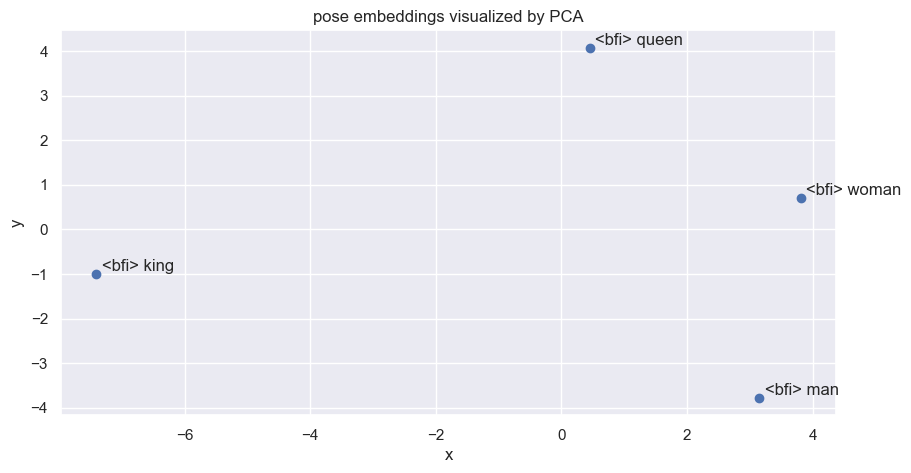

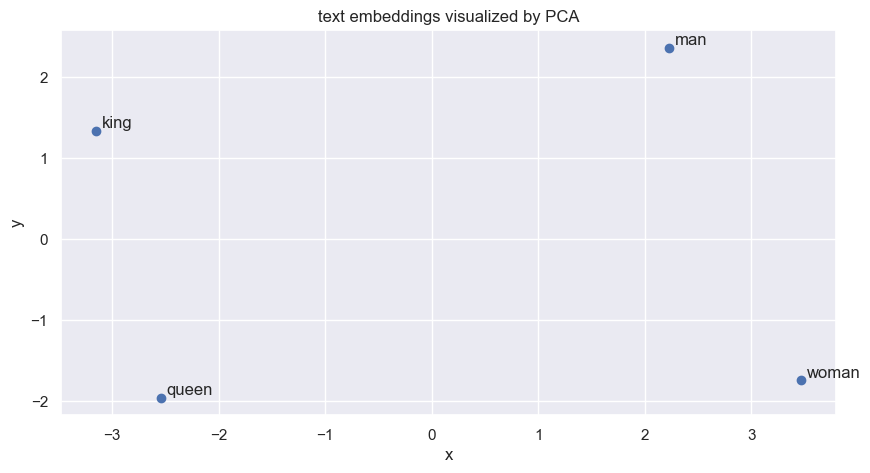

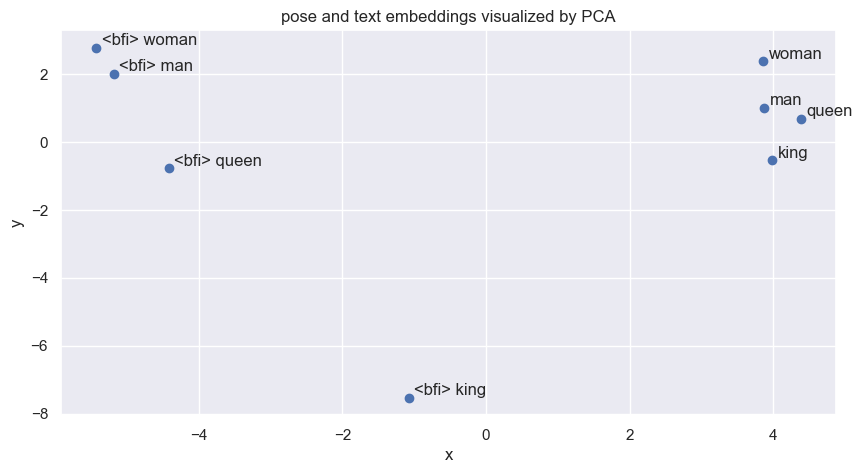

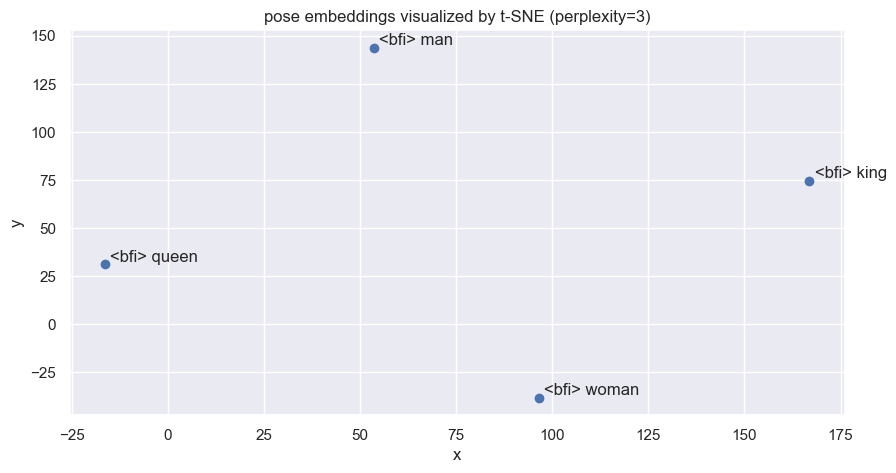

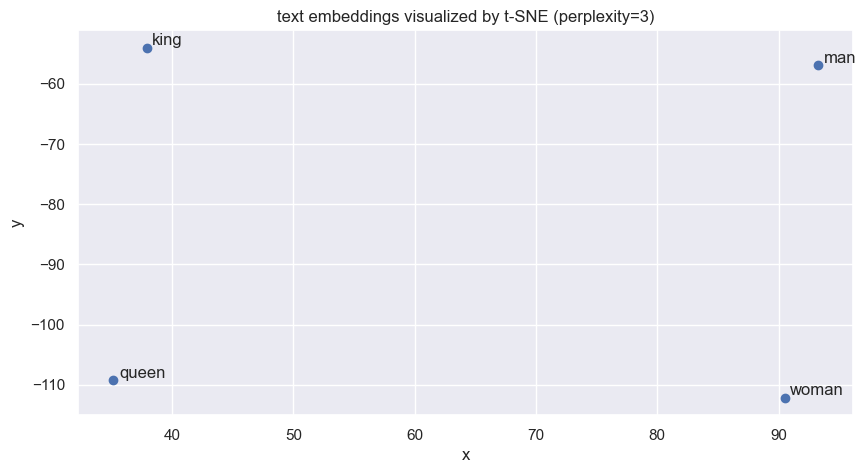

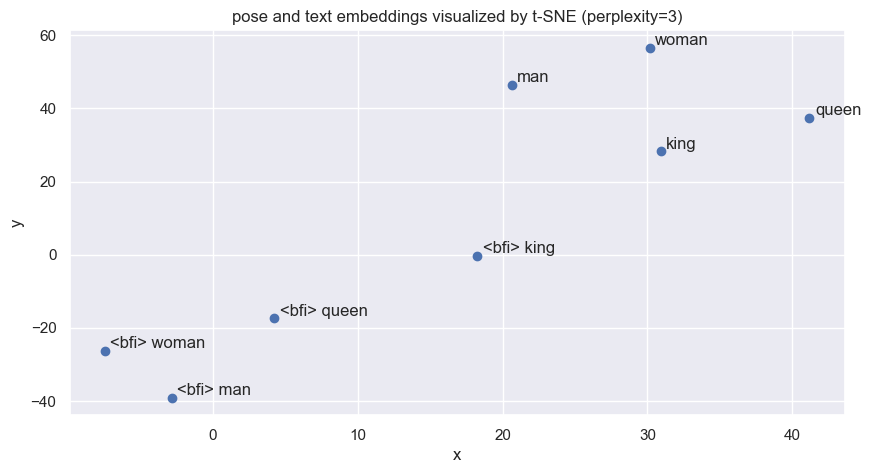

In [20]:
visualize_embeddings(text_prompts, pose_embeddings=pose_embeddings)
visualize_embeddings(text_prompts, pose_embeddings=None, text_embeddings=text_embeddings)
visualize_embeddings(text_prompts, pose_embeddings=pose_embeddings, text_embeddings=text_embeddings)

visualize_embeddings(text_prompts, pose_embeddings=pose_embeddings, model_name='t-SNE')
visualize_embeddings(text_prompts, pose_embeddings=None, text_embeddings=text_embeddings, model_name='t-SNE')
visualize_embeddings(text_prompts, pose_embeddings=pose_embeddings, text_embeddings=text_embeddings, model_name='t-SNE', perplexity=3)

It seems that PCA presents text/pose well individually, whereas t-SNE offers a great visualization of their combined representation.

Based on this example, we can say that the contrastive learning process indeed made the embedding space of sign language align to the text one, which was initilized by the pretrained BERT weights. But the text and pose spaces are clearly separate as shown by the distance between text and pose embeddings in the combined plots.

## The country and capital example (LIS)

We try to reproduce one more complex example in the pose space of another sign language (LIS), following Figure 2 from one of the *word2vec* papers ([Mikolov et al. 2013](https://arxiv.org/abs/1310.4546)).

In [21]:
%%capture

text_prompts = [
    '<en> <ise> China',
    '<en> <ise> Beijing',
    '<en> <ise> Russia',
    '<en> <ise> Moscow',
    '<en> <ise> Japan',
    '<en> <ise> Tokyo',
    '<en> <ise> Turkey',
    '<en> <ise> Ankara',
    '<en> <ise> Poland',
    '<en> <ise> Warsaw',
    '<en> <ise> Germany',
    '<en> <ise> Berlin',
    '<en> <ise> France',
    '<en> <ise> Paris',
    '<en> <ise> Italy',
    '<en> <ise> Rome',
    '<en> <ise> Greece',
    '<en> <ise> Athens',
    '<en> <ise> Spain',
    '<en> <ise> Madrid',
    '<en> <ise> Portugal',
    '<en> <ise> Lisbon',
]
video_urls = [
    'https://media.spreadthesign.com/video/mp4/17/497264.mp4',
    'https://media.spreadthesign.com/video/mp4/17/199998.mp4',
    'https://media.spreadthesign.com/video/mp4/17/505730.mp4',
    'https://media.spreadthesign.com/video/mp4/17/275002.mp4',
    'https://media.spreadthesign.com/video/mp4/17/650226.mp4',
    'https://media.spreadthesign.com/video/mp4/17/290758.mp4',
    'https://media.spreadthesign.com/video/mp4/17/506531.mp4',
    'https://media.spreadthesign.com/video/mp4/17/287293.mp4',
    'https://media.spreadthesign.com/video/mp4/17/496665.mp4',
    'https://media.spreadthesign.com/video/mp4/17/463725.mp4',
    'https://media.spreadthesign.com/video/mp4/17/462553.mp4',
    'https://media.spreadthesign.com/video/mp4/17/199999.mp4',
    'https://media.spreadthesign.com/video/mp4/17/461744.mp4',
    'https://media.spreadthesign.com/video/mp4/17/466031.mp4',
    'https://media.spreadthesign.com/video/mp4/17/500170.mp4',
    'https://media.spreadthesign.com/video/mp4/17/505741.mp4',
    'https://media.spreadthesign.com/video/mp4/17/500478.mp4',
    'https://media.spreadthesign.com/video/mp4/17/463101.mp4',
    'https://media.spreadthesign.com/video/mp4/17/177497.mp4',
    'https://media.spreadthesign.com/video/mp4/17/287513.mp4',
    'https://media.spreadthesign.com/video/mp4/17/496675.mp4',
    'https://media.spreadthesign.com/video/mp4/17/287505.mp4',
]

text_embeddings = embed_text(text_prompts)
pose_embeddings = embed_video(video_urls)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 96332  100 96332    0     0  1024k      0 --:--:-- --:--:-- --:--:-- 1033k


Loading video ...
Estimating pose ...


I0000 00:00:1771928784.085301  143172 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2 Pro
0it [00:00, ?it/s]INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1771928784.176686  143254 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928784.192234  143252 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928784.194854  143253 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928784.194967  143258 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928784.195590  143256 inference_feedback_manager.cc:114] Feedback 

Saving to disk ...


100  377k  100  377k    0     0  2383k      0 --:--:-- --:--:-- --:--:-- 2375k


...

Saving to disk ...


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  114k  100  114k    0     0   129k      0 --:--:-- --:--:-- --:--:--  129k


Loading video ...
Estimating pose ...


I0000 00:00:1771928873.711149  146393 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
0it [00:00, ?it/s]W0000 00:00:1771928873.790684  146432 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928873.805172  146432 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928873.806931  146432 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928873.807080  146429 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928873.807232  146431 inference_feedback_manager.cc:114] Feedback 

Saving to disk ...


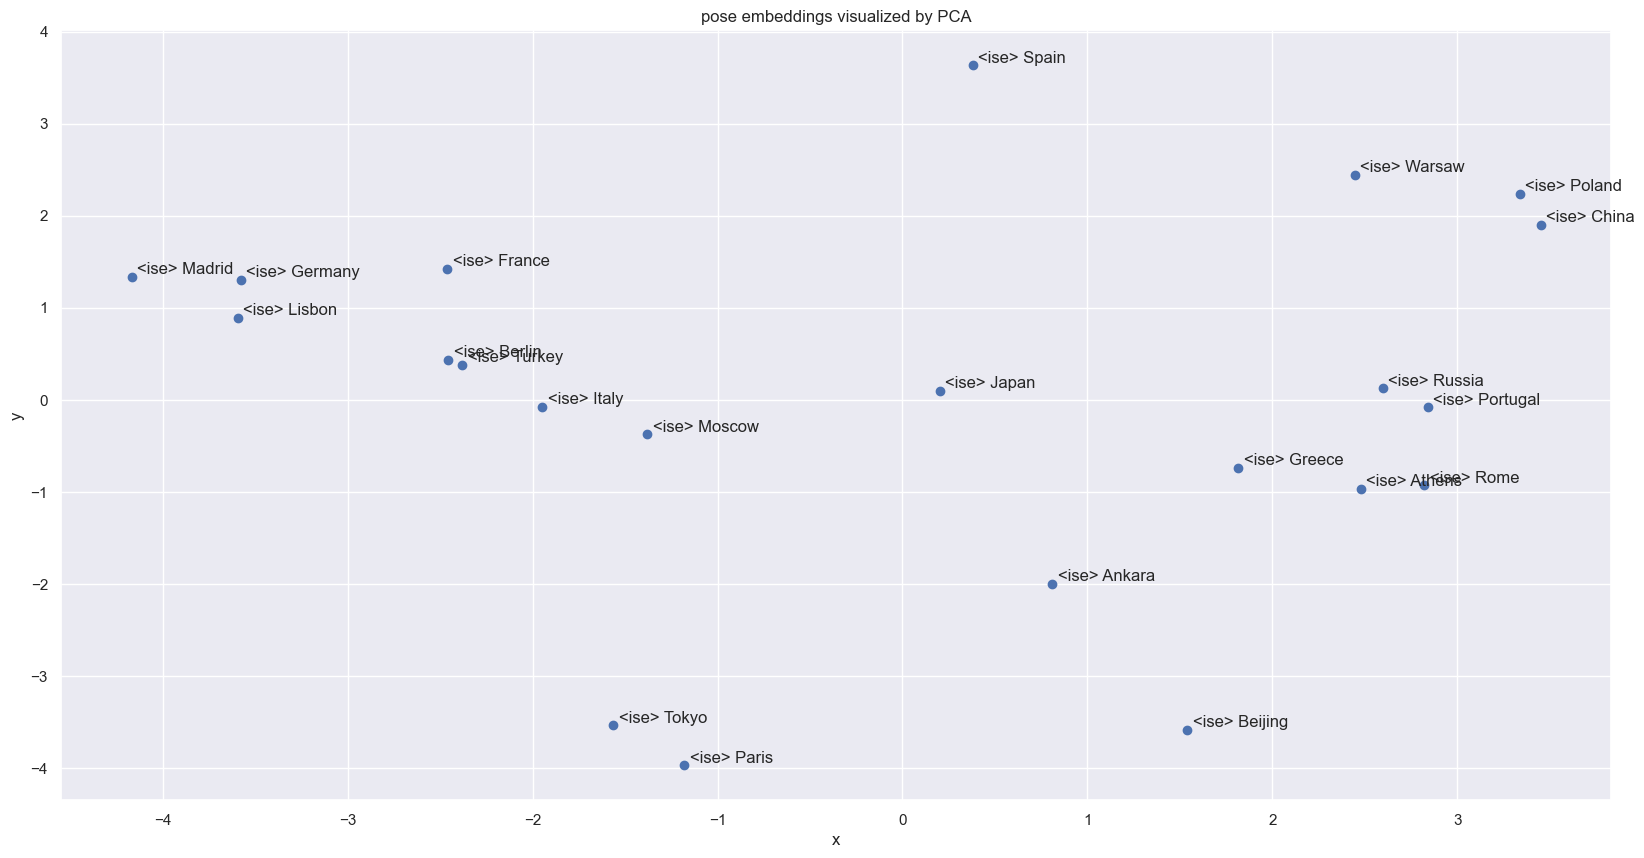

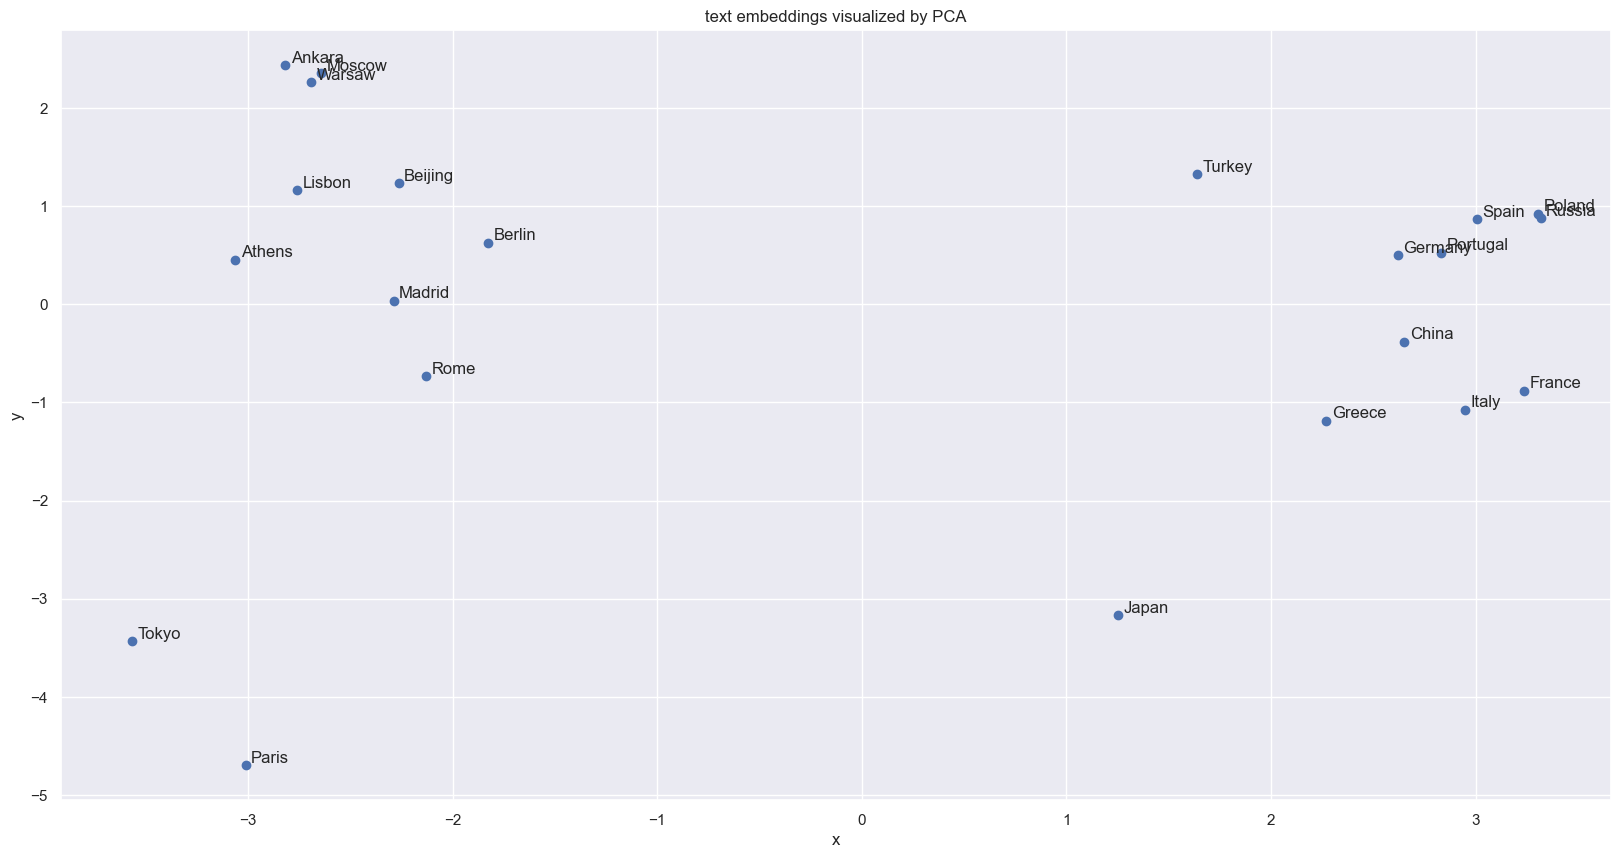

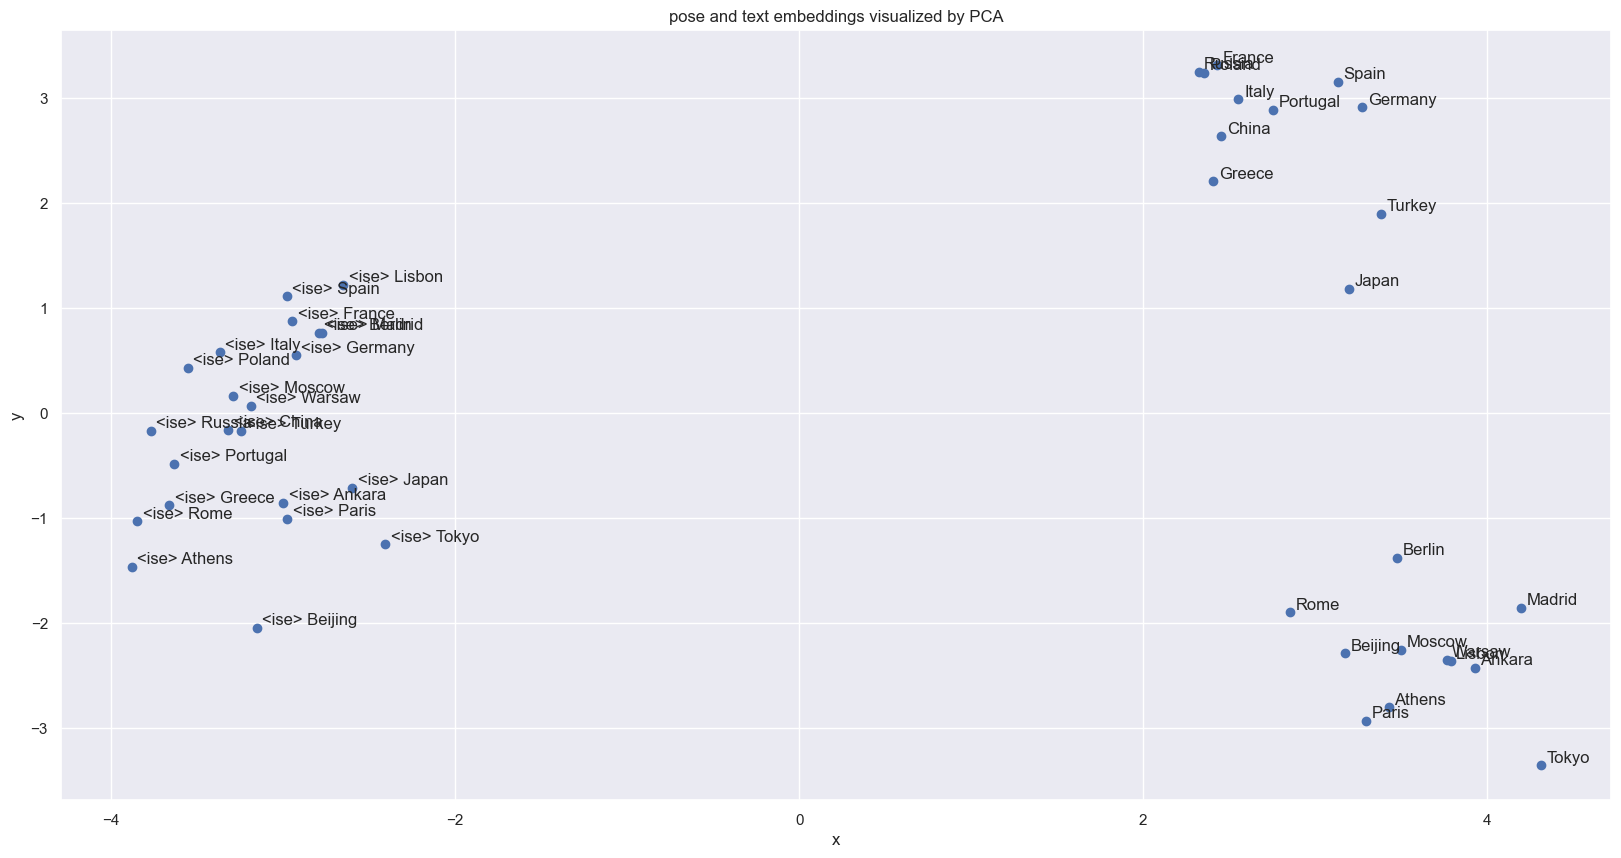

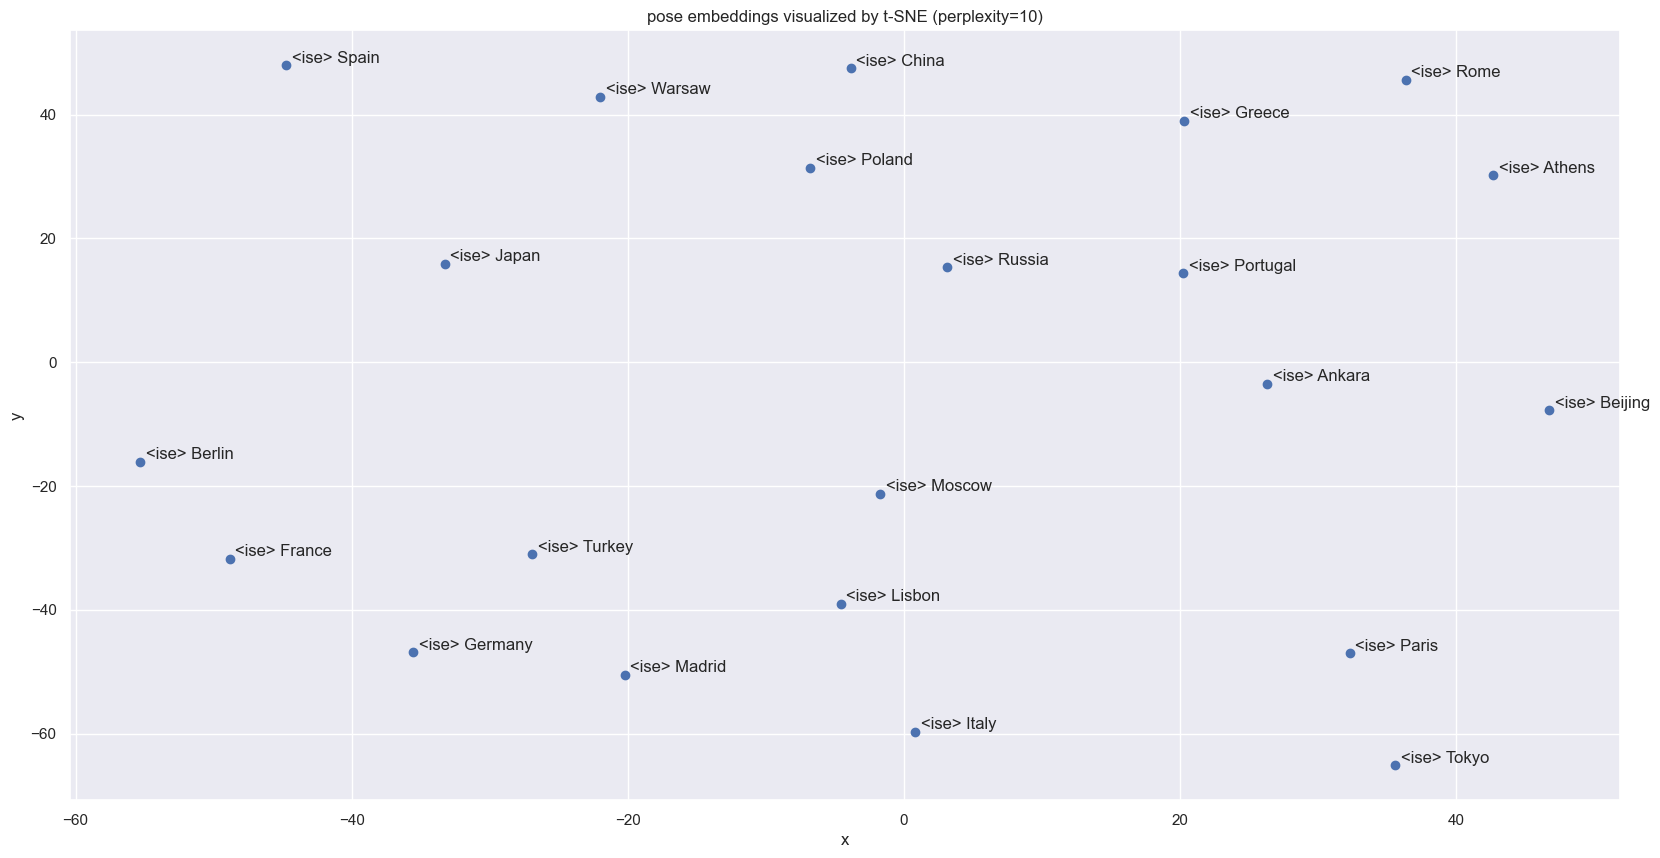

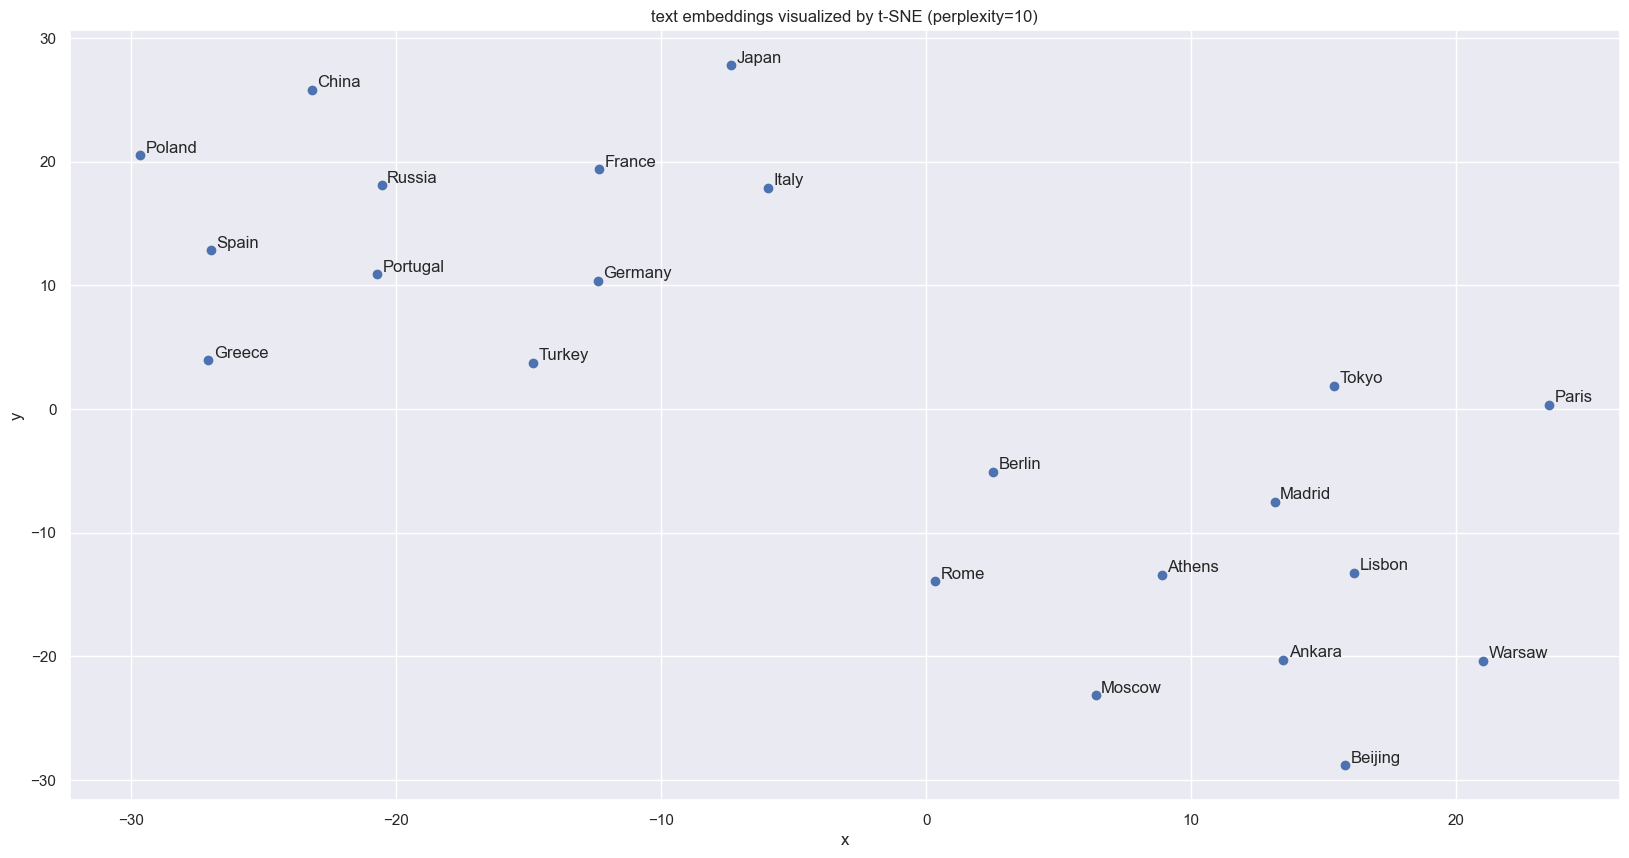

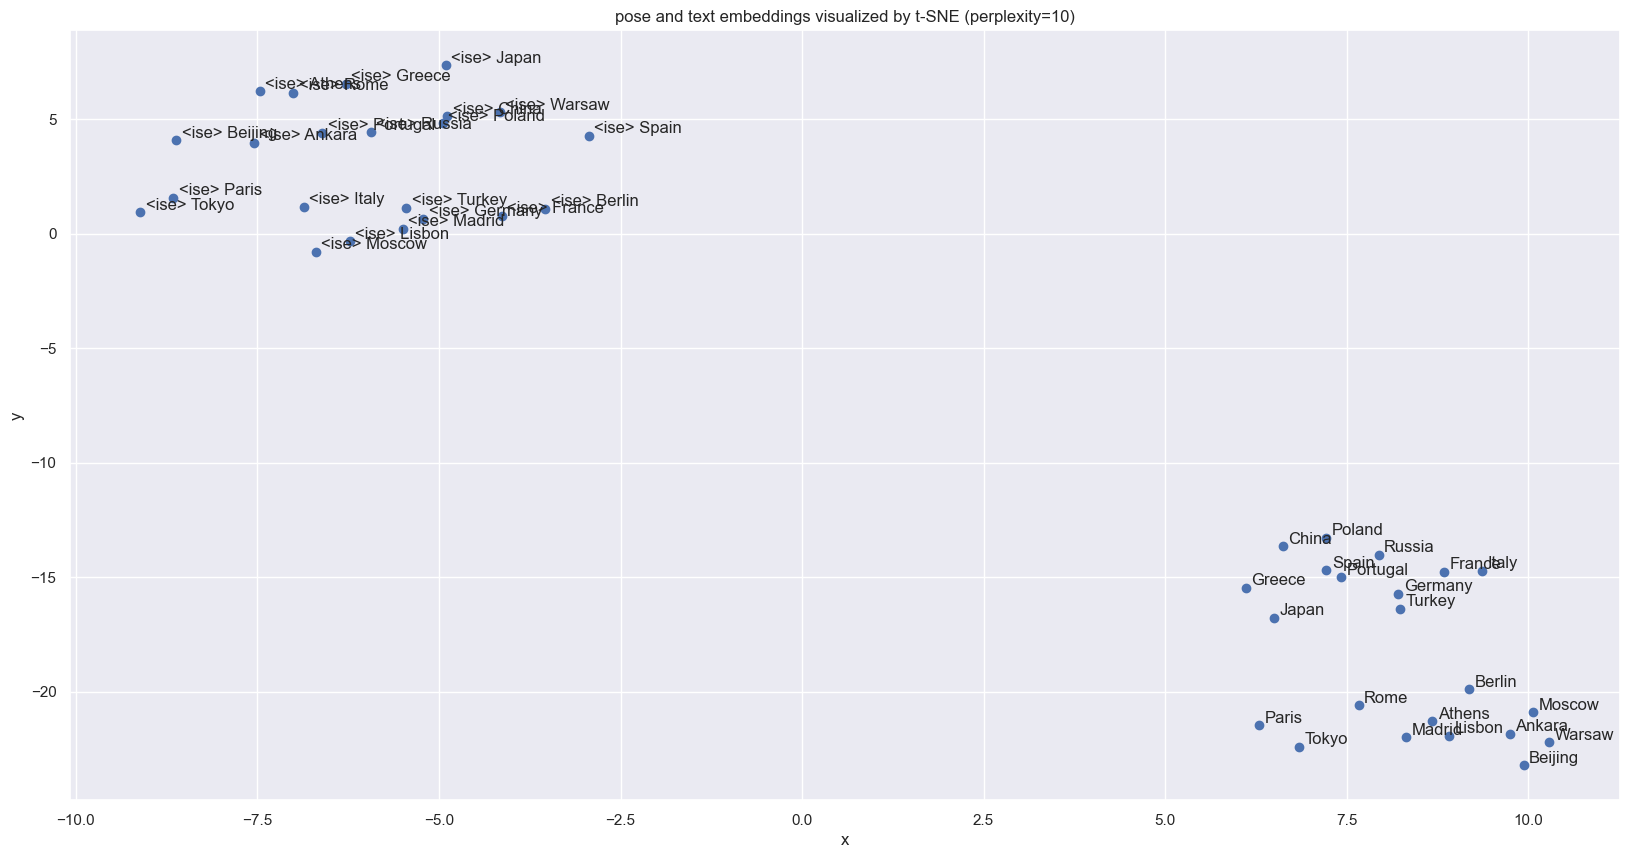

In [22]:
figsize = (20, 10)
perplexity = 10

visualize_embeddings(text_prompts, pose_embeddings=pose_embeddings, figsize=figsize)
visualize_embeddings(text_prompts, pose_embeddings=None, text_embeddings=text_embeddings, figsize=figsize)
visualize_embeddings(text_prompts, pose_embeddings=pose_embeddings, text_embeddings=text_embeddings, figsize=figsize)

visualize_embeddings(text_prompts, pose_embeddings=pose_embeddings, model_name='t-SNE', figsize=figsize, perplexity=perplexity)
visualize_embeddings(text_prompts, pose_embeddings=None, text_embeddings=text_embeddings, model_name='t-SNE', figsize=figsize, perplexity=perplexity)
visualize_embeddings(text_prompts, pose_embeddings=pose_embeddings, text_embeddings=text_embeddings, model_name='t-SNE', figsize=figsize, perplexity=perplexity)

This one is a bit tricky. We can see the text space still presents two nice clusters for counties and capitals, but for the pose space it is quite mixed up.

An interpretation is that sign language poses are not discrete semantic symbols like text, they are rather continious signals of human motion that contains  individual variations in every realization. It is possible that two signs have great visual resemblelance but totally different semantics, and vice versa.

## The king and queen example multilingual

Now we take the poses of all sign languages in Spreadthesign (pre-calculated) for the king and queen example, i.e., 32 for man/woman and 37 for king/queen to see how their embeddings are distributed.

In [23]:
import glob


pose_paths = glob.glob('sp_poses/*.pose')
print(pose_paths)

multilingual_pose_embeddings = embed_pose(pose_paths)
print(multilingual_pose_embeddings.shape)

[]


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

Define the text prompts and visualize. This time we only look at the pose embeddings and use only the t-SNE algorithm. A bigger `perplexity` value encourages the algorithm to look at more neighbours (global structure).

In [24]:
text_prompts = []
for pose_path in pose_paths:
  term, sign_language = pose_path.split('/')[-1].replace('.pose', '').split('_')
  text_prompt = f'<en> <{sign_language}> {term}'
  text_prompts.append(text_prompt)

figsize = (20, 10)

visualize_embeddings(text_prompts, pose_embeddings=multilingual_pose_embeddings, model_name='t-SNE', figsize=figsize, perplexity=3)
visualize_embeddings(text_prompts, pose_embeddings=multilingual_pose_embeddings, model_name='t-SNE', figsize=figsize, perplexity=35)

NameError: name 'multilingual_pose_embeddings' is not defined

The clustering seems to be dominated by the sign language type more than the concept and it is hard to disentangle them even though we expect that each universal concept could be embeeded in the space cross-linguically.

With increased `perplexity`, we see the embeddings of a same concept occasionally manage to come across each other. For example, "woman" in `rsl` (Russian Sign Language) leaves its own language cluster at bottom to approach "woman" in `ukl` (Ukrainian Sign Language) at bottom right of the plot.

Interestingly, this example makes sense in the great visual resemblance of the sign "woman" between [Russian Sign Language](https://media.spreadthesign.com/video/mp4/12/12886.mp4) and [Ukrainian Sign Language](https://media.spreadthesign.com/video/mp4/31/111506.mp4).

We try one more visualization with a pair of sign languages to simplify the plot.

In [ ]:
selected_languages = ['csl', 'fsl']

text_prompts = []
indices = []
for index, pose_path in enumerate(pose_paths):
  term, sign_language = pose_path.split('/')[-1].replace('.pose', '').split('_')
  if sign_language in selected_languages:
    text_prompt = f'<en> <{sign_language}> {term}'
    text_prompts.append(text_prompt)
    indices.append(index)

figsize = (10, 5)

visualize_embeddings(text_prompts, pose_embeddings=multilingual_pose_embeddings[indices], model_name='t-SNE', figsize=figsize, perplexity=5)

Again, the clustering is dominated by the language but a nice isomorphism for the analogy relationship is presented, similarly to the previous plot about text/pose embeddings, this time between the pose embeddings of different sign languages.

## The king and queen example multi-realization (ASL)

There is usually only one realization of a sign in Spreadthesign, so we take  examples from the test set of the [ASL Citizen dataset](https://www.microsoft.com/en-us/research/project/asl-citizen/) (10+ poses by different signers for each of the four signs) to see how multiple realizations of signs are distributed in the space. We only look at ASL to eliminate the influcence of sign language type as seen above.

We query a special checkpoint finetuned on the ASL Citizen training set to get the embeddings.

In [ ]:
import glob


pose_paths = glob.glob('asl_citizen_poses/*.pose')
print(pose_paths)

text_prompts = []
for pose_path in pose_paths:
  _, term = pose_path.split('/')[-1].replace('.pose', '').split('-')
  sign_language = 'ase'
  text_prompt = f'<en> <{sign_language}> {term}'
  text_prompts.append(text_prompt)

multi_realization_pose_embeddings = embed_pose(pose_paths, model_name='asl_citizen')
print(multi_realization_pose_embeddings.shape)

# visualize_embeddings(text_prompts, pose_embeddings=multi_realization_pose_embeddings, figsize=figsize)
visualize_embeddings(text_prompts, pose_embeddings=multi_realization_pose_embeddings, model_name='t-SNE', figsize=figsize, perplexity=15, seed=1)

So there are basically four clusters for the four signs, and the analogy relationship is maintained, except that now we measure the direction from "king" to "queen" to be the cluster center of the "king"s to the cluster center of the "queen"s.

Finally, we make one nicer plot for the figure in the paper ;)

In [ ]:
from collections import defaultdict

def visualize_embeddings_v1(text_prompts, pose_embeddings=None, text_embeddings=None, model_name='PCA', figsize=(10, 5), perplexity=15, seed=1):
  if pose_embeddings is not None and text_embeddings is not None:
    embeddings = np.concatenate([pose_embeddings, text_embeddings])
    title = 'pose and text embeddings'
  else:
    embeddings = pose_embeddings if text_embeddings is None else text_embeddings
    title = 'pose embeddings' if text_embeddings is None else 'text embeddings'

  if model_name == 'PCA':
    model = PCA(n_components=2, random_state=seed)
  elif model_name == 't-SNE':
    model = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=perplexity, random_state=seed)

  title = title + f' visualized by {model_name}'
  if model_name == 't-SNE':
    title = title + f' (perplexity={perplexity})'

  embeddings_2d = model.fit_transform(embeddings)
  x, y = embeddings_2d.T

  pose_terms = [' '.join(prompt.split(' ')[1:]) for prompt in text_prompts]
  text_terms = [' '.join(prompt.split(' ')[2:]) for prompt in text_prompts]
  terms = []
  if pose_embeddings is not None:
    terms = terms + pose_terms
  if text_embeddings is not None:
    terms = terms + text_terms

  terms_groupped = defaultdict(list)
  for i, term in enumerate(terms):
    terms_groupped[term].append(i)

  term_to_color = {
      '<ase> QUEEN': '#1f77b4',
      '<ase> KING': '#ff7f0e',
      '<ase> WOMAN': '#2ca02c',
      '<ase> MAN': '#d62728',
  }
  term_to_marker = {
      '<ase> QUEEN': "v",
      '<ase> KING': "^",
      '<ase> WOMAN': "o",
      '<ase> MAN': "s",
  }

  fig, ax = plt.subplots(figsize=figsize)

  for term, ids in terms_groupped.items():
    ax.scatter(x[ids], y[ids], c=term_to_color[term], marker=term_to_marker[term])
    ax.scatter(x[ids].mean(), y[ids].mean(), c=term_to_color[term], marker=term_to_marker[term], s=1000)

    ax.annotate(
        term.split(' ')[1],
        (x[ids].mean(), y[ids].mean()),
        xytext=(0, 20),
        textcoords='offset points',
        fontsize=24
    )

  plt.title(title)
  plt.xlabel('x')
  plt.ylabel('y')
  plt.show()

visualize_embeddings_v1(text_prompts, pose_embeddings=multi_realization_pose_embeddings, model_name='t-SNE', figsize=figsize, perplexity=15, seed=1)

<!-- ## Ask the model: what is the most iconic sign across languages -->

# Isolated sign language recognition (TODO)

In [5]:
import os
print("Python:", __import__('sys').version)
print("CWD:", os.getcwd())
print("house.pose exists:", os.path.exists('house.pose'))

Python: 3.12.2 (main, Feb 25 2024, 03:55:42) [Clang 17.0.6 ]
CWD: /Users/piotr/Projects/Thesis/fairseq/examples/MMPT
house.pose exists: True


In [6]:
import requests
import json
import io
import base64

import numpy as np

from pose_format import Pose

def query_embedding(data):
  modality = 'text' if 'text' in data.keys() else 'pose'
  url = f"https://pub.cl.uzh.ch/demo/sign_clip/{modality}"
  headers = {'Content-Type': 'application/json'}
  payload = json.dumps(data)
  response = requests.request("GET", url, headers=headers, data=payload)
  result = json.loads(response.text)
  return np.asarray(result['embeddings'])

def embed_text(text, model_name='default'):
  return query_embedding({"text": text, "model_name": model_name})

def read_pose(pose_path):
  with open(pose_path, "rb") as f:
    buffer = f.read()
    pose = Pose.read(buffer)
  return pose

def embed_pose(pose, model_name='default'):
  poses = pose if type(pose) == list else [pose]
  poses = [pose if isinstance(pose, Pose) else read_pose(pose) for pose in poses]
  pose_data = []
  for pose in poses:
    memory_file = io.BytesIO()
    pose.write(memory_file)
    encoded = base64.b64encode(memory_file.getvalue())
    pose_data.append(encoded.decode('ascii'))
  return query_embedding({"pose": pose_data, "model_name": model_name})

def test_pose(pose_path, text_prompts):
  pose = read_pose(pose_path)
  text_embeddings = embed_text(text_prompts)
  pose_embeddings = embed_pose(pose)
  print('Text embedding shape:', text_embeddings.shape)
  print('Pose embedding shape:', pose_embeddings.shape)
  scores = np.matmul(pose_embeddings, text_embeddings.T)
  for t in zip(text_prompts, scores.squeeze().tolist()):
    print(t)

print("Functions defined OK")

Functions defined OK


In [7]:
text_prompts = [
    '<en> <ase> house', # ASL
    '<en> <ase> HOUSE', # ASL
    '<en> <ase> House', # ASL
    '<en> <gsg> house', # DGS
    '<en> <gss> house', # GSL
    '<en> <fsl> house', # LSF
    '<en> <ase> sun',
    '<en> <ase> China',
    '<en> <ase> hello',
    '<en> <ase> how are you?',
]

test_pose('house.pose', text_prompts)

Text embedding shape: (10, 768)
Pose embedding shape: (1, 768)
('<en> <ase> house', 94.98855272640962)
('<en> <ase> HOUSE', 81.75644655202905)
('<en> <ase> House', 92.77885981172577)
('<en> <gsg> house', 81.70444755669426)
('<en> <gss> house', 76.60331555076216)
('<en> <fsl> house', 84.33944891941398)
('<en> <ase> sun', 71.58123497843606)
('<en> <ase> China', 77.51585091236149)
('<en> <ase> hello', 77.983635412374)
('<en> <ase> how are you?', 79.70954246766193)


In [17]:
import os
import subprocess

def embed_video(video_url):
  video_urls = video_url if type(video_url) == list else [video_url]
  pose_paths = []

  for video_url in video_urls:
    video_path = video_url.split('/')[-1]
    pose_path = video_path.replace('.mp4', '.pose')

    if not os.path.exists(pose_path):
      download_cmd = f'curl {video_url} --output {video_path}'
      pose_estimation_cmd = f'video_to_pose -i {video_path} --format mediapipe -o {pose_path}'
      subprocess.run(f'{download_cmd} && {pose_estimation_cmd}', shell=True)

    pose_paths.append(pose_path)

  poses = [read_pose(pose_path) for pose_path in pose_paths]
  return embed_pose(poses)

text_prompts = [
    '<en> <bfi> king',
    '<en> <bfi> queen',
    '<en> <bfi> man',
    '<en> <bfi> woman',
]
video_urls = [
    'https://media.spreadthesign.com/video/mp4/1/467203.mp4',
    'https://media.spreadthesign.com/video/mp4/1/17946.mp4',
    'https://media.spreadthesign.com/video/mp4/1/12899.mp4',
    'https://media.spreadthesign.com/video/mp4/1/12891.mp4'
]

text_embeddings = embed_text(text_prompts)
pose_embeddings = embed_video(video_urls)
print("text_embeddings shape:", text_embeddings.shape)
print("pose_embeddings shape:", pose_embeddings.shape)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 65372  100 65372    0     0   322k      0 --:--:-- --:--:-- --:--:--  322k


Loading video ...
Estimating pose ...


I0000 00:00:1771928643.914816  141157 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1771928644.048183  141360 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928644.061393  141358 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928644.198038  141367 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928644.198090  141365 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928644.199018  141360 inference_feedback_manager.cc:114] Feedback manager requires a

Saving to disk ...
Loading video ...
Estimating pose ...


I0000 00:00:1771928648.094574  141480 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
0it [00:00, ?it/s]W0000 00:00:1771928648.174482  141520 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928648.190852  141523 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928648.202437  141516 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928648.203408  141523 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928648.203891  141519 inference_feedback_manager.cc:114] Feedback 

...

Saving to disk ...


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 76626  100 76626    0     0  1227k      0 --:--:-- --:--:-- --:--:-- 1247k


Loading video ...
Estimating pose ...


I0000 00:00:1771928654.890510  141665 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2 Pro
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
0it [00:00, ?it/s]W0000 00:00:1771928654.968832  141703 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928654.981437  141710 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928654.983131  141707 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928654.983248  141710 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1771928654.983786  141703 inference_feedback_manager.cc:114] Feedback 

Saving to disk ...
text_embeddings shape: (4, 768)
pose_embeddings shape: (4, 768)


In [25]:
import os

os.makedirs('sp_poses', exist_ok=True)

# Map the downloaded video IDs to their concepts (from cell 26)
bsl_poses = {
    '467203.pose': 'king_bfi.pose',
    '17946.pose':  'queen_bfi.pose',
    '12899.pose':  'man_bfi.pose',
    '12891.pose':  'woman_bfi.pose',
}

import shutil
for src, dst in bsl_poses.items():
    if os.path.exists(src):
        shutil.copy(src, f'sp_poses/{dst}')
        print(f"Copied {src} -> sp_poses/{dst}")

print("\nsp_poses contents:", os.listdir('sp_poses'))

Copied 467203.pose -> sp_poses/king_bfi.pose
Copied 17946.pose -> sp_poses/queen_bfi.pose
Copied 12899.pose -> sp_poses/man_bfi.pose
Copied 12891.pose -> sp_poses/woman_bfi.pose

sp_poses contents: ['man_bfi.pose', 'queen_bfi.pose', 'king_bfi.pose', 'woman_bfi.pose']
